In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt

In [ ]:
#Load dữ liệu
file_path = '/content/drive/My Drive/Project_DataMining/data/processed/data_final.csv'
import pandas as pd
df=pd.read_csv(file_path)

In [ ]:
# Copy dataset
df_coppy = df.copy()

# Define numerical columns (excluding target 'Hair_Loss')
numerical_columns = ['Age']

# Standardize numerical data
scaler = StandardScaler()
df_coppy[numerical_columns] = scaler.fit_transform(df_coppy[numerical_columns])

# Split features and target
X = df_coppy.drop(columns=['Hair_Loss'])
y = df['Hair_Loss'].copy()

# Convert target to binary classification (0/1)
y = y.apply(lambda x: 1 if x >= 0.5 else 0)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Split data using the first fold
for train_index, test_index in skf.split(X, y):
    X_train_split, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_split, y_test = y.iloc[train_index], y.iloc[test_index]
    break

In [ ]:
# Sử dụng SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto', k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train_split, y_train_split)

In [ ]:
# Định nghĩa các grid search parameter cho Logistic Regression và SVM
param_grid_logistic = {
    'C': [0.01, 0.1, 1, 10],        # Hệ số phạt
    'solver': ['lbfgs', 'liblinear'],  # Các solver khác nhau
    'max_iter': [100, 200, 300],    # Số vòng lặp tối đa
}

param_grid_svc = {
    'C': [0.01, 0.1, 1, 10],    # Mức độ phạt
    'gamma': ['scale', 'auto'], # Tham số gamma cho SVM
    'kernel': ['rbf', 'linear'], # Loại kernel
}

In [ ]:
# Khởi tạo các mô hình và GridSearchCV
grid_logistic = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_logistic,
    n_jobs=-1,
    cv=5,
    scoring='recall'
)

grid_svc = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svc,
    n_jobs=-1,
    cv=5,
    scoring='recall'
)

In [ ]:
# Models
models = {
    'Logistic Regression': GridSearchCV(
        LogisticRegression(random_state=42), param_grid_logreg, cv=skf, scoring='recall', n_jobs=-1
    ),
    'SVM': GridSearchCV(
        SVC(), param_grid_svm, cv=skf, scoring='recall', n_jobs=-1
    )
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

🔍 Tuning model: Logistic Regression ...
✅ Best params for Logistic Regression: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}


<ipython-input-39-b6e6f20a1e8c>:28: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


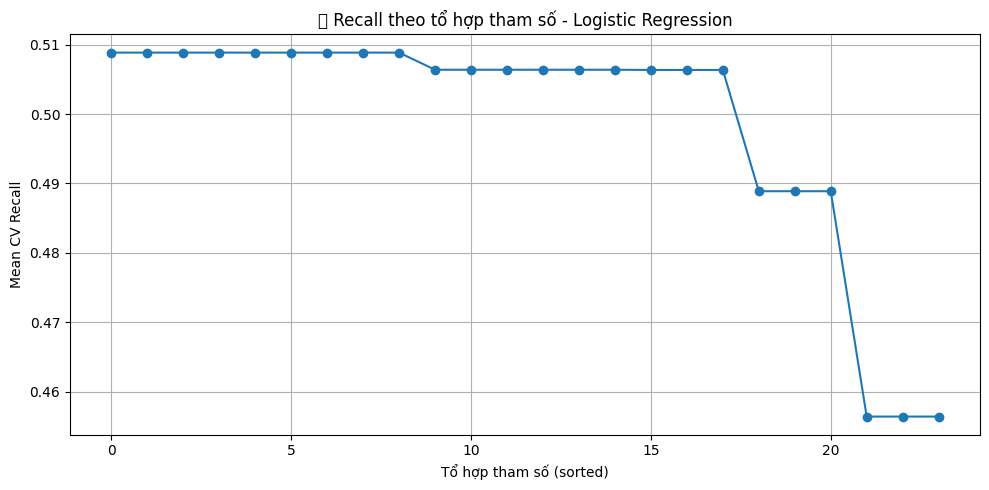

📊 Mean cross-validation Recall (KFold): 0.5372
🎯 Accuracy: 0.5100
🎯 Precision (weighted): 0.5101
Recall (weighted): 0.5100
🎯 Recall (positive class): 0.5152
🧩 Confusion Matrix:
[[51 50]
 [48 51]]
------------------------------------------------------------
🔍 Tuning model: SVM ...
✅ Best params for SVM: {'C': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}


<ipython-input-39-b6e6f20a1e8c>:28: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


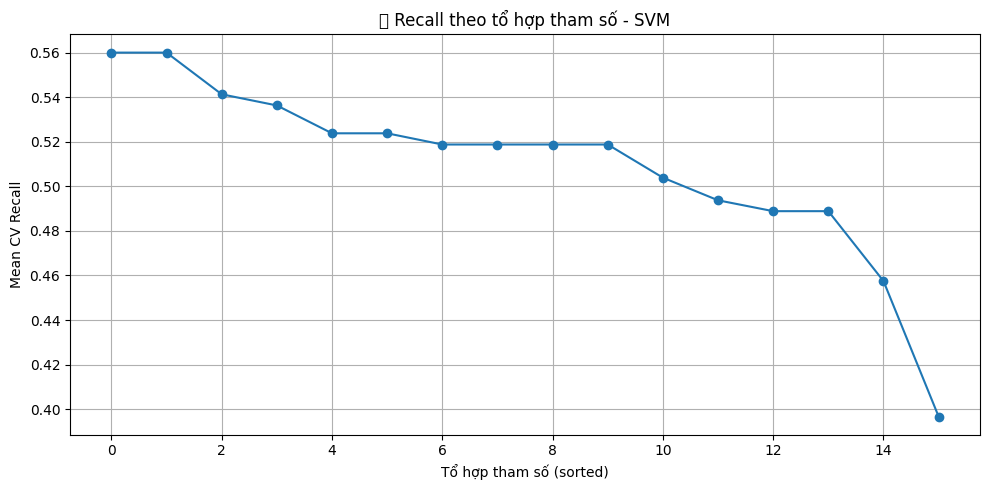

📊 Mean cross-validation Recall (KFold): 0.6000
🎯 Accuracy: 0.4900
🎯 Precision (weighted): 0.4904
Recall (weighted): 0.4900
🎯 Recall (positive class): 0.5354
🧩 Confusion Matrix:
[[45 56]
 [46 53]]
------------------------------------------------------------


In [ ]:
# Đưa các mô hình vào dictionary để lặp qua
models = {
    'Logistic Regression': grid_logistic,
    'SVM': grid_svc
}

# KFold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, grid in models.items():
    print(f"🔍 Tuning model: {name} ...")

    # Huấn luyện GridSearchCV
    grid.fit(X_train, y_train)

    print(f"✅ Best params for {name}: {grid.best_params_}")
    best_model = grid.best_estimator_

    # 🎨 Trực quan hóa kết quả GridSearchCV
    results = pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending=False)

    plt.figure(figsize=(10, 5))
    plt.plot(range(len(results)), results['mean_test_score'], marker='o')
    plt.title(f'🔍 Recall theo tổ hợp tham số - {name}')
    plt.xlabel('Tổ hợp tham số (sorted)')
    plt.ylabel('Mean CV Recall')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Đánh giá cross-validation ngoài (KFold)
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='recall')
    print(f"📊 Mean cross-validation Recall (KFold): {cv_scores.mean():.4f}")

    # Huấn luyện và dự đoán
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    # Lưu mô hình
    filename = f'/content/drive/My Drive/Project_DataMining/output/finetune_{name.replace(" ", "_")}.pkl'
    joblib.dump(best_model, filename)

    # Đánh giá kết quả
    print(f"🎯 Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"🎯 Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall (weighted): {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"🎯 Recall (positive class): {recall_score(y_test, y_pred, pos_label=1):.4f}")
    print("🧩 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 60)